**Practical 1**

**Aim : Document Indexing and Retrieval**
* Implement an inverted index construction algorithm.
* Build a simple document retrieval system using the constructed index.

In [1]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

# 1. Define the documents in a dictionary for easy reference
docs = {
    "Document 1": "The quick brown fox jumped over the lazy dog",
    "Document 2": "The lazy dog slept in the sun"
}

# 2. Build the matrix (CountVectorizer automatically lowercases, tokenizes, and removes stopwords)
vectorizer = CountVectorizer(stop_words='english')
term_matrix = vectorizer.fit_transform(docs.values())

# 3. Create a Pandas DataFrame to easily map terms to documents
df = pd.DataFrame(term_matrix.toarray(), columns=vectorizer.get_feature_names_out(), index=docs.keys())

# 4. Print the Inverted Index
print("INVERTED INDEX:\n")
for term in df.columns:
    # Filter for documents where the term frequency is greater than 0
    appearances = df[df[term] > 0][term]

    # Format and print the output
    postings = [f"{doc} ({freq})" for doc, freq in appearances.items()]
    print(f"{term} -> {', '.join(postings)}")

INVERTED INDEX:

brown -> Document 1 (1)
dog -> Document 1 (1), Document 2 (1)
fox -> Document 1 (1)
jumped -> Document 1 (1)
lazy -> Document 1 (1), Document 2 (1)
quick -> Document 1 (1)
slept -> Document 2 (1)
sun -> Document 2 (1)


**Practical 2**

**Aim : Retrieval Models**
* Implement the Boolean retrieval model and process queries.
* Implement the vector space model with TF-IDF weighting and cosine similarity

In [2]:
#A. Boolean Retrieval Model

import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

# 1. Define the documents
docs = {
    1: "apple banana orange",
    2: "apple banana",
    3: "banana orange",
    4: "apple"
}

# 2. Build a Binary Matrix (True if term is in doc, False otherwise)
vectorizer = CountVectorizer(binary=True)
matrix = vectorizer.fit_transform(docs.values()).toarray()
df = pd.DataFrame(matrix, columns=vectorizer.get_feature_names_out(), index=docs.keys()).astype(bool)

# 3. Perform Boolean Queries using simple Pandas logic
result_and = df[df['apple'] & df['banana']].index.tolist()
result_or  = df[df['apple'] | df['orange']].index.tolist()
result_not = df[~df['orange']].index.tolist()

# 4. Print Results
print("Documents containing 'apple' AND 'banana':", result_and)
print("Documents containing 'apple' OR 'orange':", result_or)
print("Documents NOT containing 'orange':", result_not)

Documents containing 'apple' AND 'banana': [1, 2]
Documents containing 'apple' OR 'orange': [1, 2, 3, 4]
Documents NOT containing 'orange': [2, 4]


In [3]:
#B. Vector Space Model (TF-IDF & Cosine Similarity)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 1. Define sets
train_set = ["The sky is blue.", "The sun is bright."]
test_set = ["The sun in the sky is bright."]

# 2. Initialize TfidfVectorizer (Combines CountVectorizer & TfidfTransformer)
# Note: 'english' automatically uses the built-in stopword list, saving an NLTK import!
vectorizer = TfidfVectorizer(stop_words='english')

# 3. Fit and transform the documents
train_tfidf = vectorizer.fit_transform(train_set)
test_tfidf = vectorizer.transform(test_set)

# 4. Calculate Cosine Similarity automatically
similarities = cosine_similarity(test_tfidf, train_tfidf)

# 5. Print Results
print("Vocabulary:", vectorizer.get_feature_names_out())
print("\nSimilarity Scores (Query vs Doc 1, Query vs Doc 2):\n", similarities)

Vocabulary: ['blue' 'bright' 'sky' 'sun']

Similarity Scores (Query vs Doc 1, Query vs Doc 2):
 [[0.40824829 0.81649658]]


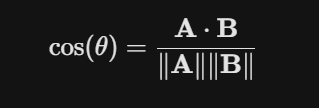

**Practical 3**

**Aim : Spelling Correction in IR Systems**
* Develop a spelling correction module using edit distance algorithms.
* Integrate the spelling correction module into an information retrieval
system.

In [4]:
import nltk

# 1. Define the strings
str1 = "sunday"
str2 = "saturday"

# 2. Calculate the edit distance automatically
distance = nltk.edit_distance(str1, str2)

# 3. Print the result
print(f"Edit Distance is: {distance}")

Edit Distance is: 3


**Practical 4**

**Aim : Evaluation Metrics for IR Systems**
* Calculate precision, recall, and F-measure for a given set of retrieval results.
* Use an evaluation toolkit to measure average precision and other
evaluation metrics.

In [7]:
#A. Precision, Recall, and F-Measure

from sklearn.metrics import precision_score, recall_score, f1_score

# 1. Define the universe of documents and your sets
docs = ["doc1", "doc2", "doc3", "doc4"]
retrieved_set = {"doc1", "doc2", "doc3"}
relevant_set = {"doc1", "doc4"}

# 2. Convert sets to binary arrays (1 if document is in the set, 0 if not)
y_pred = [1 if d in retrieved_set else 0 for d in docs]
y_true = [1 if d in relevant_set else 0 for d in docs]

# 3. Calculate and print metrics instantly
print(f"Precision: {precision_score(y_true, y_pred)}")
print(f"Recall: {recall_score(y_true, y_pred)}")
print(f"F-measure: {f1_score(y_true, y_pred)}")

Precision: 0.3333333333333333
Recall: 0.5
F-measure: 0.4


In [8]:
#B. Average Precision

from sklearn.metrics import average_precision_score

# 1. Define Ground Truth and Model Scores
y_true_b = [0, 1, 1, 0, 1, 1]
y_scores = [0.1, 0.4, 0.35, 0.8, 0.65, 0.9]

# 2. Calculate and print Average Precision
print(f"\nAverage precision-recall score: {average_precision_score(y_true_b, y_scores)}")


Average precision-recall score: 0.8041666666666667


**Practical 5**

**Aim : Text Categorization**
* Implement a text classification algorithm (e.g., Naive Bayes or Support Vector Machines)
* Train the classifier on a labelled dataset and evaluate its performance.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

# 1. Load data and combine features in one step
df = pd.read_csv("dataset_file_path")
X = (df["covid"] + " " + df["fever"]).astype(str)
y = df["flu"]

# 2. Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Create a Pipeline (Bundles the Vectorizer and Classifier together!)
model = make_pipeline(CountVectorizer(), MultinomialNB())

# 4. Train the model (It vectorizes and trains simultaneously)
model.fit(X_train, y_train)

# 5. Evaluate the model (It vectorizes the test set automatically)
print("Classification Report:\n", classification_report(y_test, model.predict(X_test)))

# 6. Load new unseen data and predict instantly
df_new = pd.read_csv("test_file_path")
new_X = (df_new["covid"] + " " + df_new["fever"]).astype(str)

# Predict without needing a separate vectorizer.transform() step!
predictions = model.predict(new_X)
print("Predictions generated successfully!")

**Practical 6**

**Aim : Clustering for Information Retrieval**
* Implement a clustering algorithm (e.g., K-means or hierarchical clustering).
* Apply the clustering algorithm to a set of documents and evaluate the clustering results.

In [10]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.pipeline import make_pipeline

documents = [
    "Cats are known for their agility and grace",
    "Dogs are often called man's best friend",
    "Some dogs are trained to assist people with disabilities",
    "The sun rises in the east and sets in the west",
    "Many cats enjoy climbing trees and chasing toys"
]

# 1. Bundle the Vectorizer and KMeans algorithm together
model = make_pipeline(TfidfVectorizer(), KMeans(n_clusters=3, random_state=0))

# 2. Fit the model and generate cluster labels in exactly one line
clusters = model.fit_predict(documents)

# 3. Use Pandas to create a clean, highly readable table of the results
df = pd.DataFrame({'Cluster': clusters, 'Document': documents})

print("T074 Kermeen\n")
print(df.sort_values(by='Cluster').to_string(index=False))

T074 Kermeen

 Cluster                                                 Document
       0 Some dogs are trained to assist people with disabilities
       1           The sun rises in the east and sets in the west
       1          Many cats enjoy climbing trees and chasing toys
       2                  Dogs are often called man's best friend
       2               Cats are known for their agility and grace


**Practical 7**

**Aim : Web Crawling and Indexing**
* Develop a web crawler to fetch and index web pages
* Handle challenges such as robots.txt, dynamic content, and crawling delays.

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

documents = [
    "Cats are known for their agility and grace",
    "Dogs are often called man's best friend",
    "Some dogs are trained to assist people with disabilities",
    "The sun rises in the east and sets in the west",
    "Many cats enjoy climbing trees and chasing toys"
]

# 1. Vectorize the text directly
X = TfidfVectorizer().fit_transform(documents)

# 2. Fit K-Means and extract cluster labels in one step
labels = KMeans(n_clusters=3, random_state=0).fit_predict(X)

# 3. Print the results
print("T074 Kermeen\nCluster labels:")
for i, label in enumerate(labels, 1): # starting enumerate at 1 replaces (i+1)
    print(f"Document {i}: Cluster {label}")

T074 Kermeen
Cluster labels:
Document 1: Cluster 2
Document 2: Cluster 2
Document 3: Cluster 0
Document 4: Cluster 1
Document 5: Cluster 1


**Practical 8**

**Aim : Link Analysis and PageRank**
* Implement the PageRank algorithm to rank web pages based on link analysis.
* Apply the PageRank algorithm to a small web graph and analyze the results.

In [14]:
import networkx as nx

# Define the web graph
pages = {
    "android.com": ["developer.android.com", "source.android.com"],
    "developer.android.com": ["android.com", "source.android.com"],
    "source.android.com": ["android.com"]
}

# 1. Build a Directed Graph directly from your dictionary
G = nx.DiGraph(pages)

# 2. Calculate PageRank (increasing max_iter to allow convergence)
ranks = nx.pagerank(G, max_iter=100)

# 3. Display Results
for page, score in ranks.items():
    print(f"{page} : {round(score, 4)}")

android.com : 0.4327
developer.android.com : 0.2339
source.android.com : 0.3333


**Practical 9**

**Aim : Learning to Rank**
*  Implement a learning to rank algorithm (e.g., RankSVM or RankBoost).
*  Train the ranking model using labelled data and evaluate its effectiveness.

In [15]:
import numpy as np
from sklearn.svm import LinearSVC
from sklearn.metrics import ndcg_score

# 1. Define Dataset
X = np.array([[3, 2, 1], [2, 1, 0], [0, 1, 2], [1, 2, 0], [2, 1, 3], [1, 0, 2]])
relevance = np.array([3, 2, 1, 3, 1, 2])
queries = np.array([1, 1, 1, 2, 2, 2])

# 2. Build Pairwise Data (The Pythonic Way)
X_pairs, y_pairs = [], []
for q in np.unique(queries):
    idx = np.where(queries == q)[0]
    for i in idx:
        for j in idx:
            if relevance[i] != relevance[j]:
                X_pairs.append(X[i] - X[j])
                # Ternary operator assigns +1 or -1 in a single line
                y_pairs.append(1 if relevance[i] > relevance[j] else -1)

# 3. Train the RankSVM model instantly
model = LinearSVC().fit(X_pairs, y_pairs)

# 4. Evaluate and Print Average NDCG using a list comprehension
ndcg_scores = [ndcg_score([relevance[queries == q]], [model.decision_function(X[queries == q])]) for q in np.unique(queries)]
print(f"Average NDCG Score: {np.mean(ndcg_scores):.4f}")

Average NDCG Score: 0.9475


**Practical 10**

**Aim : Advanced Topics in Information Retrieval**
* Implement a text summarization algorithm (e.g., extractive or abstractive).
* Build a question-answering system using techniques such as information extraction

In [22]:
#A. Extractive Text Summarization

import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from nltk.tokenize import sent_tokenize
import nltk

# Download required resources
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

text = """
Information Retrieval is the process of obtaining relevant information
from a large collection of data. It plays an important role in search engines.
Text summarization helps in reducing the size of documents while preserving
important information. Automatic summarization is widely used in news
applications and research domains.
"""

sentences = sent_tokenize(text)

# 1. Automatically count word frequencies and remove stopwords
vectorizer = CountVectorizer(stop_words='english')
word_matrix = vectorizer.fit_transform(sentences)

# 2. Score sentences by summing their word counts (row sums)
scores = np.array(word_matrix.sum(axis=1)).flatten()

# 3. Find the indices of the top 2 highest-scoring sentences
top_indices = scores.argsort()[-2:][::-1]

# 4. Print the summary in original order
summary = ' '.join([sentences[i] for i in sorted(top_indices)])
print("Summary:\n", summary)

#B. Question-Answering System (Using TF-IDF & Cosine Similarity)
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from nltk.tokenize import sent_tokenize

text = """
Information Retrieval deals with the storage and retrieval of information.
Search engines use IR techniques to retrieve relevant documents.
Natural Language Processing helps computers understand human language.
"""
sentences = sent_tokenize(text)
question = input("Enter your question: ")

# 1. Vectorize the document sentences and the question automatically
vectorizer = TfidfVectorizer(stop_words='english')
sentence_vectors = vectorizer.fit_transform(sentences)
question_vector = vectorizer.transform([question])

# 2. Calculate how similar the question is to each sentence
similarities = cosine_similarity(question_vector, sentence_vectors).flatten()

# 3. Find the index of the sentence with the highest similarity score
best_idx = np.argmax(similarities)

# 4. Display the answer if a match exists
if similarities[best_idx] > 0:
    print("Answer:", sentences[best_idx])
else:
    print("Answer not found in the document.")

Summary:
 
Information Retrieval is the process of obtaining relevant information
from a large collection of data. Text summarization helps in reducing the size of documents while preserving
important information.
Enter your question: information retrieval used for
Answer: 
Information Retrieval deals with the storage and retrieval of information.
